# Загрузка метаданных FMA, исследование, подготовка данных

## Настройка окружения и импорты

In [ ]:
import sys
from pathlib import Path

# Добавляем корень проекта в PYTHONPATH
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(f"Корень проекта: {PROJECT_ROOT}")

In [ ]:
# Основные библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

# Игнорируем предупреждения
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from src.data.config import paths, audio_params

print("=== Пути к данным ===")
paths.print_info()

print("\n=== Аудио параметры ===")
audio_params.print_info()

## Загрузка метаданных

In [ ]:
tracks_path = paths.get_tracks_csv()
features_path = paths.get_features_csv()
genres_path = paths.get_genres_csv()

print(f"Tracks.csv:  {tracks_path}")
print(f"Features.csv: {features_path}")
print(f"Genres.csv:  {genres_path}")
print(f"Файлы существуют: {tracks_path.exists() and features_path.exists() and genres_path.exists()}")

In [ ]:
tracks = pd.read_csv(tracks_path, header=[0, 1], index_col=0)

print(f"Форма tracks: {tracks.shape}")
print(f"Индекс: {tracks.index.name}")
print(f"Колонки (первые 10):")
print(tracks.columns[:10])
tracks.head()

In [ ]:
features = pd.read_csv(features_path, header=[0, 1, 2], index_col=0)

print(f"Форма features: {features.shape}")
print(f"Первые 5 колонок признаков: {features.columns[:5].tolist()}")
print(f"Последние 5 колонок: {features.columns[-5:].tolist()}")
features.head()

In [ ]:
genres = pd.read_csv(genres_path, index_col=0)

print(f"Форма genres: {genres.shape}")
genres.head()

## Исследование структуры данных

In [ ]:
print("Уровни колонок в tracks:")
for level in tracks.columns.levels:
    print(f"  - {level}")

In [ ]:
print("Уровни колонок в features:")
for level in features.columns.levels:
    print(f"  - {level}")

In [ ]:
subset_counts = tracks['set', 'subset'].value_counts()
print("Распределение по подмножествам (Small/Medium/Large):")
subset_counts

plt.figure(figsize=(8, 5))
sns.barplot(x=subset_counts.index, y=subset_counts.values)
plt.title("Количество треков по подмножествам FMA", fontsize=14)
plt.xlabel("Подмножество")
plt.ylabel("Количество треков")
for i, v in enumerate(subset_counts.values):
    plt.text(i, v + 500, str(v), ha='center')
plt.tight_layout()
plt.savefig(paths.results_dir / 'subset_distribution.png', dpi=150)
plt.show()

## Фильтрация: берём только MEDIUM subset
`medium = medium + small = !large`

In [20]:
medium_mask = tracks['set', 'subset'] != 'large'
tracks_medium = tracks[medium_mask].copy()

print(f"Треков в Medium: {len(tracks_medium)}")
print(f"Ожидалось: ~25,000 для FMA Medium")

# %%
# Жанры в Medium
genres_medium = tracks_medium['track', 'genre_top']
print(f"Уникальных жанров: {genres_medium.nunique()}")
print(f"\nЖанры с количеством треков:")
genre_counts = genres_medium.value_counts()
genre_counts

Треков в Medium: 25000
Ожидалось: ~25,000 для FMA Medium
Уникальных жанров: 16

Жанры с количеством треков:


(track, genre_top)
Rock                   7103
Electronic             6314
Experimental           2251
Hip-Hop                2201
Folk                   1519
Instrumental           1350
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
Name: count, dtype: int64

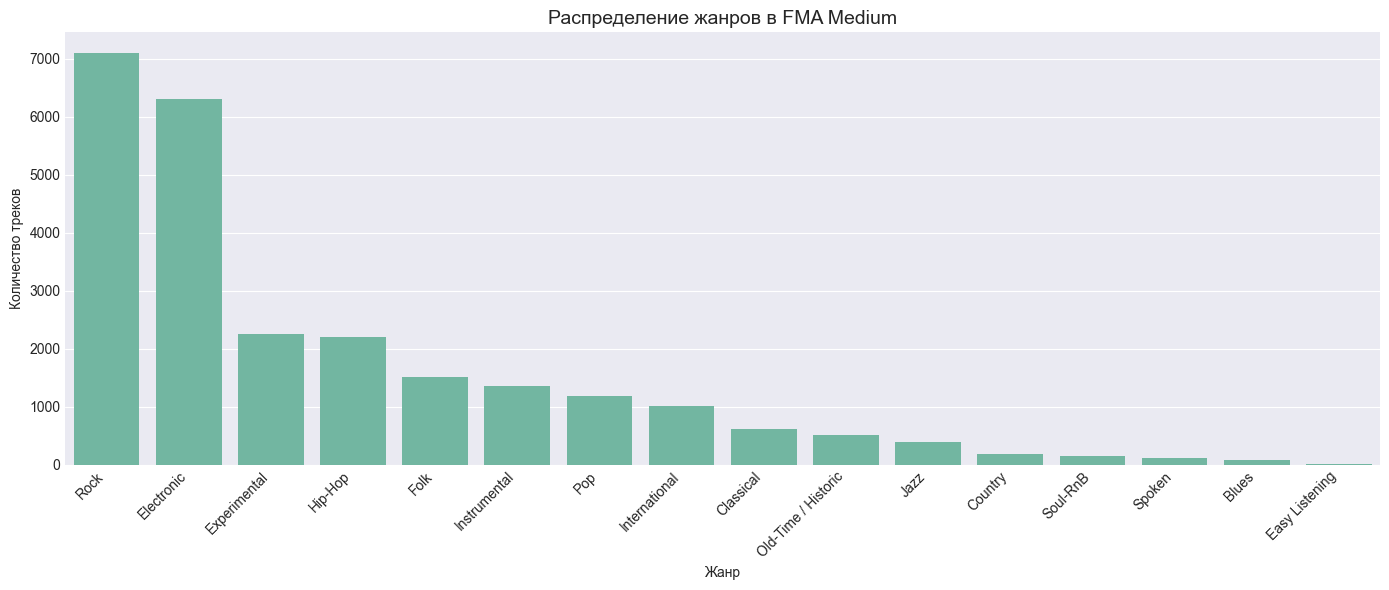

In [21]:
plt.figure(figsize=(14, 6))
genre_counts_sorted = genre_counts.sort_values(ascending=False)
sns.barplot(x=genre_counts_sorted.index, y=genre_counts_sorted.values)
plt.title("Распределение жанров в FMA Medium", fontsize=14)
plt.xlabel("Жанр")
plt.ylabel("Количество треков")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(paths.results_dir / 'genre_distribution.png', dpi=150)
plt.show()


In [24]:
print(f"Треков без жанра (NaN): {genres_medium.isna().sum()}")
print(f"Треков с жанром: {genres_medium.notna().sum()}")

tracks_medium_clean = tracks_medium[genres_medium.notna()].copy()
print(f"После удаления NaN: {len(tracks_medium_clean)} треков")

Треков без жанра (NaN): 0
Треков с жанром: 25000
После удаления NaN: 25000 треков


## Фильтрация редких жанров

In [28]:
MIN_SAMPLES_PER_GENRE = 10

genre_counts_clean = tracks_medium_clean['track', 'genre_top'].value_counts()
rare_genres = genre_counts_clean[genre_counts_clean < MIN_SAMPLES_PER_GENRE].index
common_genres = genre_counts_clean[genre_counts_clean >= MIN_SAMPLES_PER_GENRE].index

print(f"Редкие жанры (<{MIN_SAMPLES_PER_GENRE} треков):")
for g in rare_genres:
    print(f"  - {g}: {genre_counts_clean[g]} треков")

Редкие жанры (<10 треков):


In [29]:
tracks_filtered = tracks_medium_clean[
    tracks_medium_clean['track', 'genre_top'].isin(common_genres)
].copy()

print(f"\nПосле удаления редких жанров: {len(tracks_filtered)} треков")
print(f"Осталось жанров: {len(common_genres)}")
print(f"\nИтоговое распределение:")
tracks_filtered['track', 'genre_top'].value_counts()


После удаления редких жанров: 25000 треков
Осталось жанров: 16

Итоговое распределение:


(track, genre_top)
Rock                   7103
Electronic             6314
Experimental           2251
Hip-Hop                2201
Folk                   1519
Instrumental           1350
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
Name: count, dtype: int64

## Разделение по официальной разметке

In [36]:
train_mask = tracks_filtered['set', 'split'] == 'training'
val_mask = tracks_filtered['set', 'split'] == 'validation'
test_mask = tracks_filtered['set', 'split'] == 'test'

In [39]:
total = train_mask.sum() + val_mask.sum() + test_mask.sum()
print(f"Треков: {len(tracks_filtered)}")
print(f"Сумма по маскам: {total}")
assert total == len(tracks_filtered), "Не все треки попали в разбиение!"

Треков: 25000
Сумма по маскам: 25000


In [40]:
train_idx = tracks_filtered[train_mask].index
val_idx = tracks_filtered[val_mask].index
test_idx = tracks_filtered[test_mask].index

print(f"\nРазмеры выборок (официальное разбиение):")
print(f"  Train: {len(train_idx)} ({len(train_idx)/len(tracks_filtered)*100:.1f}%)")
print(f"  Val:   {len(val_idx)} ({len(val_idx)/len(tracks_filtered)*100:.1f}%)")
print(f"  Test:  {len(test_idx)} ({len(test_idx)/len(tracks_filtered)*100:.1f}%)")


Размеры выборок (официальное разбиение):
  Train: 19922 (79.7%)
  Val:   2505 (10.0%)
  Test:  2573 (10.3%)


## Сопоставление признаков и меток

In [41]:
common_ids = tracks_filtered.index.intersection(features.index)
print(f"Общих треков (tracks ∩ features): {len(common_ids)}")

if len(common_ids) != len(tracks_filtered):
    print(f"Предупреждение: {len(tracks_filtered) - len(common_ids)} треков нет в features.csv")

Общих треков (tracks ∩ features): 25000


In [42]:
X_all = features.loc[tracks_filtered.index].copy()
y_all = tracks_filtered.loc[:, ('track', 'genre_top')].copy()

print(f"X shape: {X_all.shape}")
print(f"y shape: {y_all.shape}")

X shape: (25000, 518)
y shape: (25000,)


In [43]:
print(f"NaN в X: {X_all.isna().sum().sum()}")
print(f"NaN в y: {y_all.isna().sum()}")
print(f"Infinite значения в X: {np.isinf(X_all).sum().sum()}")

NaN в X: 0
NaN в y: 0
Infinite значения в X: 0


In [45]:
X_train = X_all.loc[train_idx]
X_val = X_all.loc[val_idx]
X_test = X_all.loc[test_idx]

y_train = y_all.loc[train_idx]
y_val = y_all.loc[val_idx]
y_test = y_all.loc[test_idx]

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")


X_train: (19922, 518)
X_val:   (2505, 518)
X_test:  (2573, 518)


## Кодирование меток

In [46]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f"Количество классов: {len(label_encoder.classes_)}")
print("Соответствие жанр → код:")
for i, genre in enumerate(label_encoder.classes_):
    print(f"  {i}: {genre}")


Количество классов: 16
Соответствие жанр → код:
  0: Blues
  1: Classical
  2: Country
  3: Easy Listening
  4: Electronic
  5: Experimental
  6: Folk
  7: Hip-Hop
  8: Instrumental
  9: International
  10: Jazz
  11: Old-Time / Historic
  12: Pop
  13: Rock
  14: Soul-RnB
  15: Spoken


In [47]:
unique, counts = np.unique(y_train_encoded, return_counts=True)
print("Распределение кодов:")
for code, count in zip(unique, counts):
    genre = label_encoder.inverse_transform([code])[0]
    print(f"  {code} ({genre}): {count}")

Распределение кодов:
  0 (Blues): 58
  1 (Classical): 495
  2 (Country): 142
  3 (Easy Listening): 13
  4 (Electronic): 5050
  5 (Experimental): 1801
  6 (Folk): 1215
  7 (Hip-Hop): 1761
  8 (Instrumental): 1045
  9 (International): 814
  10 (Jazz): 306
  11 (Old-Time / Historic): 408
  12 (Pop): 945
  13 (Rock): 5681
  14 (Soul-RnB): 94
  15 (Spoken): 94


## Нормализация

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train после нормализации: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"X_val:   mean={X_val_scaled.mean():.4f}, std={X_val_scaled.std():.4f}")
print(f"X_test:  mean={X_test_scaled.mean():.4f}, std={X_test_scaled.std():.4f}")

X_train после нормализации: mean=0.0000, std=1.0000
X_val:   mean=0.0061, std=1.0880
X_test:  mean=-0.0076, std=1.0104


## Сохранение

In [49]:
import joblib
import pickle

paths.processed_data_dir.mkdir(parents=True, exist_ok=True)

In [50]:
np.save(paths.processed_data_dir / 'X_train.npy', X_train_scaled)
np.save(paths.processed_data_dir / 'X_val.npy', X_val_scaled)
np.save(paths.processed_data_dir / 'X_test.npy', X_test_scaled)
np.save(paths.processed_data_dir / 'y_train.npy', y_train_encoded)
np.save(paths.processed_data_dir / 'y_val.npy', y_val_encoded)
np.save(paths.processed_data_dir / 'y_test.npy', y_test_encoded)

In [51]:
joblib.dump(scaler, paths.processed_data_dir / 'scaler.pkl')
joblib.dump(label_encoder, paths.processed_data_dir / 'label_encoder.pkl')

['D:\\Projects\\PythonProject\\music-genre-classification-fma\\data\\processed\\label_encoder.pkl']

In [52]:
metadata = {
    'num_samples': len(X_all),
    'num_features': X_all.shape[1],
    'num_classes': len(label_encoder.classes_),
    'class_names': list(label_encoder.classes_),
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'split_method': 'official_fma_80_10_10',
    'artist_filtered': True,
    'active_subset': paths.active_subset,
    'feature_names': list(X_all.columns)
}

with open(paths.processed_data_dir / 'metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

In [53]:
print(f"Данные сохранены с официальным разбиением FMA")
print(f"  Train: {len(X_train)}")
print(f"  Val:   {len(X_val)}")
print(f"  Test:  {len(X_test)}")

Данные сохранены с официальным разбиением FMA
  Train: 19922
  Val:   2505
  Test:  2573


---